In [1]:
import os
path_project = os.path.dirname(os.path.abspath('.'))
import sys
sys.path.append(os.path.join(path_project, 'src'))
sys.path.append(os.path.join(path_project, 'exp/script'))
import results_saver
import options
import copy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import utility_experiment
import json

img_path = os.path.join(path_project, 'exp', 'img')
results_path = os.path.join(path_project, 'exp', 'results')
default_args = options.build_default_args(path_project)

PLOT_MARKERS = ['o', 'v', 's', 'X', 'p', '*', 'h', '^', '<', '>', 'H', 'D', 'd', 'P']
METHOD_ORDER = ["DEFAULT", "ULDP-NAIVE", "ULDP-GROUP-2", "ULDP-GROUP-8", "ULDP-SGD", "ULDP-AVG"]

## Hyper parameters


In [ ]:
# ハイパラ関係

def hp_exp_results(dataset_name, method, n_users, dist, n_total_round, version):
    print(f"method={method}, dataset_name={dataset_name}, n_users={n_users}, exp_dist={dist}, n_total_round={n_total_round}")
    exp_args = copy.deepcopy(default_args)
    exp_args.dataset_name = dataset_name
    exp_args.agg_strategy = method
    exp_args.n_users = n_users
    exp_args.hyper_parameter_tuning = 1
    exp_args.exp_dist = dist
    exp_args.n_total_round = n_total_round
    exp_args.version = version
    args = utility_experiment.build_exp_paramerters(exp_args, dataset_name, dist, method, n_users)
    result_list, hash_args = results_saver.load_results(args, path_project, hp=True)
    if len(result_list) == 0:
        print(f"No files on {hash_args} ({method}, {dataset_name}, {n_users}, {dist}, {n_total_round})")
        return None, None
    return result_list[0]["exp"], hash_args


def best_hp_info(dataset_name, method, n_users, dist, n_total_round, version=0):
    hp_result, _ = hp_exp_results(dataset_name, method, n_users, dist, n_total_round, version)
    best_params = hp_result["hp_results"]["best_params"]
    best_value = hp_result["hp_results"]["best_value"]
    return best_params, best_value


def plot_hps(dataset_name, method, n_users, dist, n_total_round, version=0):
    hp_result, hash_args = hp_exp_results(dataset_name, method, n_users, dist, n_total_round, version)
    if hp_result is None:
        return
    if hp_result["hp_results"].get("best_params") is None:
        print(f"No results on {hash_args} ({method}, {dataset_name}, {n_users}, {dist}, {n_total_round})")
        return
    if type(hp_result["hp_results"].get("best_params")) is str:
        print(f"Maybe too noisy: No results on {hash_args} ({method}, {dataset_name}, {n_users}, {dist}, {n_total_round})")
        return
    result_details = hp_result["hp_results"]["result_details"]
    if len(result_details) == 0:
        print(f"Unknown Error on {hash_args} ({method}, {dataset_name}, {n_users}, {dist}, {n_total_round})")
        print("best_params is:", hp_result["hp_results"].get("best_params"))
        print("best_value is:", hp_result["hp_results"].get("best_value"))
        return
    x_global_learning_rate = []
    y_clippling_bound = []
    w_local_learning_rate = []
    v_local_epochs = []
    error_rate_list = []

    for i in range(len(result_details)):
        x_global_learning_rate.append(result_details[i]["params"]["global_learning_rate"])
        error_rate_list.append(result_details[i]["error_rate"])
        if method in [
            "ULDP-GROUP",
            "ULDP-NAIVE",
            "ULDP-SGD",
            "ULDP-SGD-w",
            "ULDP-SGD-s",
            "ULDP-SGD-ws",
            "ULDP-AVG",
            "ULDP-AVG-w",
            "ULDP-AVG-s",
            "ULDP-AVG-ws",
        ]:
            y_clippling_bound.append(result_details[i]["params"]["clipping_bound"])
        else:
            y_clippling_bound.append(None)

        if method in [
            "ULDP-GROUP",
            "DEFAULT",
            "ULDP-NAIVE",
            "ULDP-AVG",
            "ULDP-AVG-w",
            "ULDP-AVG-s",
            "ULDP-AVG-ws",
        ]:
            w_local_learning_rate.append(result_details[i]["params"]["local_learning_rate"])
            v_local_epochs.append(result_details[i]["params"]["local_epochs"])
        else:
            w_local_learning_rate.append(None)
            v_local_epochs.append(None)

    x_global_learning_rate = np.array(x_global_learning_rate)
    y_clippling_bound = np.array(y_clippling_bound)
    w_local_learning_rate = np.array(w_local_learning_rate)
    v_local_epochs = np.array(v_local_epochs)
    error_rate_list = np.array(error_rate_list)

    indices = np.argsort(error_rate_list)
    sorted_hp_results = []
    for i in indices:
        sorted_hp_results.append((error_rate_list[i], x_global_learning_rate[i], y_clippling_bound[i], w_local_learning_rate[i], v_local_epochs[i]))

    return sorted_hp_results


In [ ]:
# VERSION=0
# methods = ["ULDP-SGD", "ULDP-AVG", "ULDP-SGD-w", "ULDP-AVG-w", "DEFAULT", "ULDP-NAIVE"]

# dataset_names_img = ["mnist", "cifar10"]
# dists_img = [0, 1]
# n_users_list_img = [100, 10000]
# n_total_round_list_img = [50]
# group_k_list =[2, 8]

# for dataset_name in dataset_names_img:
#     for method in methods:
#         for n_users in n_users_list_img:
#             for dist in dists_img:
#                 for n_total_round in n_total_round_list_img:
#                     if method == "ULDP-GROUP":
#                         for group_k in group_k_list:
#                             method_uldp_group = method + f"-{group_k}"
#                             plot_hps(dataset_name, method, n_users, dist, n_total_round)
#                     else:
#                         plot_hps(dataset_name, method, n_users, dist, n_total_round)


# dataset_names_med = ["heart_disease", "tcga_brca"]
# n_users_list_med = [10, 100, 1000]

# for dataset_name in dataset_names_med:
#     for method in methods:
#         for n_users in n_users_list_med:
#             for n_total_round in n_total_round_list_img:
#                 if method == "ULDP-GROUP":
#                     for group_k in group_k_list:
#                         method_uldp_group = method + f"-{group_k}"
#                         plot_hps(dataset_name, method_uldp_group, n_users, None, n_total_round, VERSION)
#                 else:
#                     plot_hps(dataset_name, method, n_users, None, n_total_round, version=VERSION)

In [ ]:
VERSION=1
dataset_name = "heart_disease"
method = "ULDP-SGD"
n_users = 1000
dist = None
n_total_round = 50
plot_hps(dataset_name, method, n_users, dist, n_total_round, version=VERSION)

In [ ]:
VERSION=3
dataset_name = "tcga_brca"
method = "ULDP-AVG"
n_users = 10
dist = None
n_total_round = 100
plot_hps(dataset_name, method, n_users, dist, n_total_round, version=VERSION)

## Privacy-Utility tradeoffs

In [ ]:
def exp_results(dataset_name=None, method=None, n_users=None, dist=None, n_total_round=None, group_k=None, version=0, hashed_args=None):
    if hashed_args is None:
        exp_args = copy.deepcopy(default_args)
        exp_args.dataset_name = dataset_name
        exp_args.agg_strategy = method
        exp_args.n_users = n_users
        exp_args.exp_dist = dist
        exp_args.n_total_round = n_total_round
        if group_k:
            exp_args.group_k = group_k
        exp_args.version = version

        args = utility_experiment.build_exp_paramerters(exp_args, dataset_name, dist, method, n_users)
        result_list, hash_args = results_saver.load_results(args, path_project)
    else:
        result_list, hash_args = results_saver.load_results(args, hashed_args)

    if len(result_list) == 0:
        print(f"No files on {hash_args} ({method}, {dataset_name}, {n_users}, {dist}, {n_total_round}, {group_k})")
        return None, None
    
    exp_result_list = []
    for exp_result in result_list[0]["exp"]:
        if exp_result == "LOSS IS NAN":
            print("[WARN] include LOSS IS NAN")
            continue
        elif exp_result == "Assertion Error":
            print("[WARN] include Assertion Error")
            continue
        exp_result_list.append(exp_result)

    if len(exp_result_list) == 0:
        print("[WARN] all LOSS IS NAN")
        return None, hash_args

    return exp_result_list, hash_args


def plot_privacy_utility(exp_result_list, hash_args, prefix=""):
    print("hash_args", hash_args)

    global_test_list = []
    for exp_result in exp_result_list:
        global_test_list.extend(exp_result["global_test"])
        
    global_rounds = [round_idx for round_idx, test_acc, test_loss in global_test_list]
    global_test_acc_list = [
        test_acc for round_idx, test_acc, test_loss in global_test_list
    ]
    global_test_loss_list = [
        test_loss for round_idx, test_acc, test_loss in global_test_list
    ]
    fig, ax = plt.subplots(1, 1)
    sns.lineplot(x=global_rounds, y=global_test_acc_list, marker="o", ax=ax)
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("test accuracy", fontsize=18)
    ax.set_title("Test accuracy over rounds", fontsize=20)
    fig.savefig(
        os.path.join(results_path, hash_args, prefix + "global_test_acc.png"),
        dpi=150,
        bbox_inches="tight",
    )

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(x=global_rounds, y=global_test_loss_list, marker="o", ax=ax)
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("test loss", fontsize=18)
    ax.set_title("Test loss over rounds", fontsize=20)
    fig.savefig(
        os.path.join(results_path, hash_args, prefix + "global_test_loss.png"),
        dpi=150,
        bbox_inches="tight",
    )

    if exp_result_list[0].get('privacy_budget'):
        privacy_budget_list = exp_result_list[0]['privacy_budget']
        delta = privacy_budget_list[0][2]
        rounds = [round_idx for round_idx, eps, delta in privacy_budget_list]
        eps_list = [eps for round_idx, eps, delta in privacy_budget_list]
        fig, ax = plt.subplots(1, 1)
        sns.lineplot(x=rounds, y=eps_list, marker="o", ax=ax)
        ax.set_xlabel("round", fontsize=18)
        ax.set_yscale('log')
        ax.set_ylabel("epsilon", fontsize=18)
        ax.set_title(f"Epsilon over rounds (delta={delta})", fontsize=20)
        fig.savefig(
            os.path.join(results_path, hash_args, prefix + "global_epsilon.png"),
            dpi=150,
            bbox_inches="tight",
        )

    if exp_result_list[0].get('local_model_test'):
        n_total_round = len(exp_result_list[0]["global_test"])
        local_model_test_list = []
        for exp_result in exp_result_list:
            local_model_test_list.extend(exp_result["local_model_test"])
        local_acc_results = {"round_idx": [], "local_metric": [], "silo_id": []}
        local_loss_results = {"round_idx": [], "local_loss": [], "silo_id": []}

        for round_idx, silo_id, local_metric, local_loss in local_model_test_list:
            local_acc_results["round_idx"].append(round_idx)
            local_acc_results["local_metric"].append(local_metric)
            local_acc_results["silo_id"].append(silo_id)

            local_loss_results["round_idx"].append(round_idx)
            local_loss_results["local_loss"].append(local_loss)
            local_loss_results["silo_id"].append(silo_id)

        for round_idx, local_metric, global_loss in zip(global_rounds, global_test_acc_list, global_test_loss_list):
            local_acc_results["round_idx"].append(round_idx)
            local_acc_results["local_metric"].append(local_metric)
            local_acc_results["silo_id"].append("global")

            local_loss_results["round_idx"].append(round_idx)
            local_loss_results["local_loss"].append(global_loss)
            local_loss_results["silo_id"].append("global")

        for round_idx in range(n_total_round):
            local_acc_of_round = [
                local_acc
                for rid, local_acc in zip(
                    local_acc_results["round_idx"], local_acc_results["local_metric"]
                )
                if rid == round_idx
            ]
            local_acc_results["round_idx"].append(round_idx)
            local_acc_results["local_metric"].append(
                sum(local_acc_of_round) / len(local_acc_of_round)
            )
            local_acc_results["silo_id"].append("average")
            local_loss_of_round = [
                local_loss
                for rid, local_loss in zip(
                    local_loss_results["round_idx"], local_loss_results["local_loss"]
                )
                if rid == round_idx
            ]
            local_loss_results["round_idx"].append(round_idx)
            local_loss_results["local_loss"].append(
                sum(local_loss_of_round) / len(local_loss_of_round)
            )
            local_loss_results["silo_id"].append("average")

        fig, ax = plt.subplots(1, 1, dpi=150)
        sns.lineplot(
            x="round_idx",
            y="local_metric",
            hue="silo_id",
            data=local_acc_results,
            marker="o",
            ax=ax,
        )
        ax.set_xlabel("round", fontsize=18)
        ax.set_ylabel("local metric", fontsize=18)
        ax.set_title("Local metric over rounds", fontsize=20)
        fig.savefig(
            os.path.join(results_path, hash_args, prefix + "local_test_acc.png"),
            dpi=150,
            bbox_inches="tight",
        )

        fig, ax = plt.subplots(1, 1)
        sns.lineplot(
            x="round_idx",
            y="local_loss",
            hue="silo_id",
            data=local_loss_results,
            marker="o",
            ax=ax,
        )
        ax.set_xlabel("round", fontsize=18)
        ax.set_ylabel("local loss", fontsize=18)
        ax.set_title("Local loss over rounds", fontsize=20)
        fig.savefig(
            os.path.join(results_path, hash_args, prefix + "local_test_loss.png"),
            dpi=150,
            bbox_inches="tight",
        )


In [ ]:
# dataset_name = "tcga_brca"
# method = "ULDP-SGD"
# n_users = 1000
# group_k = None
# dist = None
# n_total_round = 50
# exp_result_list, hash_args = exp_results(dataset_name, method, n_users, dist, n_total_round, group_k)
# plot_privacy_utility(exp_result_list, hash_args)

## Medical dataset


- methods=("DEFAULT" "ULDP-NAIVE" "ULDP-GROUP" "ULDP-SGD" "ULDP-AVG")
- dataset_names=("heart_disease" "tcga_brca")
- n_users_list=(10 100 1100)
    - group_k=(4 8) for "ULDP-GROUP"


In [ ]:
marker_size = 2
alpha = 0.9

def plot_metric_per_method(dataset_name, n_users, methods, group_k_list, n_total_round, dist, version):
    utility_metric_results = {"round_idx": [], "test_metric": [], "method": []}
    loss_metric_results = {"round_idx": [], "test_loss": [], "method": []}
    for method in methods:
        if method == "ULDP-GROUP":
            for group_k in group_k_list:
                exp_result_list, hash_args = exp_results(dataset_name, method, n_users, dist, n_total_round, group_k, version)
                if exp_result_list is None:
                    continue
                global_test_list = []
                for exp_result in exp_result_list:
                    global_test_list.extend(exp_result["global_test"])
                for round_idx, test_metric, test_loss in global_test_list:
                    utility_metric_results["round_idx"].append(round_idx)
                    utility_metric_results["test_metric"].append(test_metric)
                    utility_metric_results["method"].append(method + f"-{group_k}")
                    loss_metric_results["round_idx"].append(round_idx)
                    loss_metric_results["test_loss"].append(test_loss)
                    loss_metric_results["method"].append(method + f"-{group_k}")
        else:
            exp_result_list, hash_args = exp_results(dataset_name, method, n_users, dist, n_total_round, version=version)
            if exp_result_list is None:
                continue
            global_test_list = []
            for exp_result in exp_result_list:
                global_test_list.extend(exp_result["global_test"])
            for round_idx, test_metric, test_loss in global_test_list:
                utility_metric_results["round_idx"].append(round_idx)
                utility_metric_results["test_metric"].append(test_metric)
                utility_metric_results["method"].append(method)
                loss_metric_results["round_idx"].append(round_idx)
                loss_metric_results["test_loss"].append(test_loss)
                loss_metric_results["method"].append(method)

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="test_metric",
        hue="method",
        hue_order=METHOD_ORDER,
        style="method",
        data=utility_metric_results,
        ax=ax,
        # markers=PLOT_MARKERS,
        # markersize=marker_size,
        alpha=alpha,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("Metric", fontsize=18)
    ax.set_title(f"Metric over rounds ({dataset_name}, {n_users}, {n_total_round}, {dist})", fontsize=20)
    fig.savefig(
        os.path.join(img_path, f"{dataset_name}-{n_users}-{dist}-global_test_acc_per_method.png"),
        dpi=150,
        bbox_inches="tight",
    )

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="test_loss",
        hue="method",
        hue_order=METHOD_ORDER,
        style="method",
        data=loss_metric_results,
        ax=ax,
        # markers=PLOT_MARKERS,
        # markersize=marker_size,
        alpha=alpha,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_yscale('log')
    ax.set_ylabel("test loss", fontsize=18)
    ax.set_title(f"Test loss over rounds ({dataset_name}, {n_users}, {n_total_round}, {dist})", fontsize=20)
    fig.savefig(
        os.path.join(img_path, f"{dataset_name}-{n_users}-{dist}-global_test_loss_per_method.png"),
        dpi=150,
        bbox_inches="tight",
    )


def plot_epsilon_per_method(dataset_name, n_users, methods, group_k_list, n_total_round, dist, version=0):
    privacy_results = {"round_idx": [], "epsilon": [], "method": []}
    delta = 0
    for method in methods:
        if method == "ULDP-GROUP":
            for group_k in group_k_list:
                exp_result_list, hash_args = exp_results(dataset_name, method, n_users, dist, n_total_round, group_k, version=version)
                if exp_result_list is None:
                    continue
                privacy_budget_list = exp_result_list[0]['privacy_budget']
                if len(privacy_budget_list) == 0:
                    continue
                delta = privacy_budget_list[0][2]
                for round_idx, eps, _ in privacy_budget_list:
                    privacy_results["round_idx"].append(round_idx)
                    privacy_results["epsilon"].append(eps)
                    privacy_results["method"].append(method + f"-{group_k}")

        else:
            exp_result_list, hash_args = exp_results(dataset_name, method, n_users, dist, n_total_round, version=version)
            if exp_result_list is None:
                continue
            privacy_budget_list = exp_result_list[0]['privacy_budget']
            if len(privacy_budget_list) == 0:
                continue
            delta = privacy_budget_list[0][2]
            for round_idx, eps, _ in privacy_budget_list:
                privacy_results["round_idx"].append(round_idx)
                privacy_results["epsilon"].append(eps)
                privacy_results["method"].append(method)

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="epsilon",
        hue="method",
        hue_order=METHOD_ORDER,
        data=privacy_results,
        style="method",
        # markers=PLOT_MARKERS,
        # markersize=marker_size,
        alpha=alpha,
        ax=ax,
    )
    ax.set_yscale('log')
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("epsilon", fontsize=18)
    ax.set_title(f"Epsilon over rounds (delta={delta}) ({dataset_name}, {n_users}, {n_total_round}, {dist})", fontsize=20)
    fig.savefig(
        os.path.join(img_path, f"{dataset_name}-{n_users}-{dist}-global_epsilon.png"),
        dpi=150,
        bbox_inches="tight",
    )


In [ ]:
VERSION=1
methods = ["ULDP-SGD", "ULDP-AVG", "DEFAULT", "ULDP-NAIVE", "ULDP-GROUP"]

# dataset_names_img = ["mnist", "cifar10"]
# dists_img = [0, 1]
# n_users_list_img = [100, 10000]
# n_total_round_list_img = [50]
# group_k_list =[2, 8]

VERSION=1
dataset_names_img = ["mnist"]
dists_img = [0, 1]
n_users_list_img = [100, 10000]
n_total_round_list_img = [100]
group_k_list =[2, 8]

methods = ["ULDP-SGD", "ULDP-AVG", "DEFAULT", "ULDP-NAIVE", "ULDP-GROUP"]

for dataset_name in dataset_names_img:
    for n_users in n_users_list_img:
        for dist in dists_img:
            for n_total_round in n_total_round_list_img:
                plot_metric_per_method(dataset_name, n_users, methods, group_k_list, n_total_round, dist, version=VERSION)
                plot_epsilon_per_method(dataset_name, n_users, methods, group_k_list, n_total_round, dist, version=VERSION)


# dataset_names_med = ["heart_disease", "tcga_brca"]
n_users_list_med = [10, 100, 1000]

VERSION=1
dataset_names_med = ["heart_disease"]
n_users_list_med = [10, 100, 1000]
n_total_round_list_img = [50]

for dataset_name in dataset_names_med:
    for n_users in n_users_list_med:
        for n_total_round in n_total_round_list_img:
            plot_metric_per_method(dataset_name, n_users, methods, group_k_list, n_total_round, None, version=VERSION)
            plot_epsilon_per_method(dataset_name, n_users, methods, group_k_list, n_total_round, None, version=VERSION)

VERSION=3
dataset_names_med = ["tcga_brca"]
n_users_list_med = [10, 100, 1000]
n_total_round_list_img = [100]

for dataset_name in dataset_names_med:
    for n_users in n_users_list_med:
        for n_total_round in n_total_round_list_img:
            plot_metric_per_method(dataset_name, n_users, methods, group_k_list, n_total_round, None, version=VERSION)
            plot_epsilon_per_method(dataset_name, n_users, methods, group_k_list, n_total_round, None, version=VERSION)

In [2]:
marker_size = 2
alpha = 0.9
import glob

def load_result_from_file_path(file_path: str):
    with open(file_path, "r") as json_file:
        results = json.load(json_file)
    args = results["args"]
    print(args)
    return results["exp"]

def plot_metric_per_method_by_filename(file_path: str):
    utility_metric_results = {"round_idx": [], "test_metric": [], "method": []}
    loss_metric_results = {"round_idx": [], "test_loss": [], "method": []}
    exp_result_list = load_result_from_file_path(file_path=file_path)
    global_test_list = []
    for exp_result in exp_result_list:
        global_test_list.extend(exp_result["global_test"])
    dir_name = os.path.dirname(file_path)
    for round_idx, test_metric, test_loss in global_test_list:
        utility_metric_results["round_idx"].append(round_idx)
        utility_metric_results["test_metric"].append(test_metric)
        utility_metric_results["method"].append("method")
        loss_metric_results["round_idx"].append(round_idx)
        loss_metric_results["test_loss"].append(test_loss)
        loss_metric_results["method"].append("method")

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="test_metric",
        data=utility_metric_results,
        ax=ax,
        markers=PLOT_MARKERS,
        markersize=marker_size,
        alpha=alpha,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("Metric", fontsize=18)
    ax.set_title(f"Metric over rounds", fontsize=20)
    fig.savefig(
        os.path.join(dir_name, "global_test_acc_per_method.png"),
        dpi=150,
        bbox_inches="tight",
    )

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="test_loss",
        data=loss_metric_results,
        ax=ax,
        markers=PLOT_MARKERS,
        markersize=marker_size,
        alpha=alpha,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("test loss", fontsize=18)
    ax.set_title(f"Test loss over rounds", fontsize=20)
    fig.savefig(
        os.path.join(dir_name, "global_test_loss_per_method.png"),
        dpi=150,
        bbox_inches="tight",
    )


def plot_epsilon_per_method_by_file_path(file_path: str):
    privacy_results = {"round_idx": [], "epsilon": [], "method": []}
    privacy_budget_list = load_result_from_file_path(file_path=file_path)
    dir_name = os.path.dirname(file_path)
    for round_idx, eps, _ in privacy_budget_list[0]["privacy_budget"]:
        privacy_results["round_idx"].append(round_idx)
        privacy_results["epsilon"].append(eps)
        privacy_results["method"].append("method")

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="epsilon",
        data=privacy_results,
        alpha=alpha,
        ax=ax,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("epsilon", fontsize=18)
    ax.set_title(f"Epsilon over rounds", fontsize=20)
    fig.savefig(
        os.path.join(dir_name, "global_epsilon.png"),
        dpi=150,
        bbox_inches="tight",
    )


def plot_multiple_epsilons(file_paths: list[str], setting_map: dict =None):
    n_files = len(file_paths)
    all_data = []
    for i, file_path in enumerate(file_paths):
        privacy_budget_list = load_result_from_file_path(file_path)
        all_data.append((i, privacy_budget_list[0]["privacy_budget"]))
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    if setting_map is None:
        setting_map = {i: i for i in range(n_files)}
    loss_metric_results = {"round_idx": [], "epsilon": [], "setting": []}
    for file_idx, result in all_data:
        for round_idx, epsilon, _  in result:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["epsilon"].append(epsilon)
            loss_metric_results["setting"].append(setting_map[file_idx])

    sns.lineplot(
        x="round_idx",
        y="epsilon",
        hue="setting",
        data=loss_metric_results,
        ax=ax,
        marker='o',
        markersize=4,
        alpha=1.0,
        palette="colorblind",
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("epsilon", fontsize=18)


def plot_multiple_losses(file_paths: list[str], setting_map: dict =None):
    n_files = len(file_paths)
    all_data = []
    for i, file_path in enumerate(file_paths):
        exp_result_list = load_result_from_file_path(file_path)
        global_test_list = []
        for exp_result in exp_result_list:
            global_test_list.extend(exp_result["global_test"])
            all_data.append((i, exp_result["global_test"]))
        loss_metric_results = {"round_idx": [], "test_loss": []}
        for round_idx, _, test_loss in global_test_list:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_loss"].append(test_loss)

    # fig, axes = plt.subplots(1, n_files, figsize=(n_files*3, 3), sharey=True)
    # if n_files == 1:
    #     axes = [axes]

    #     sns.lineplot(
    #         x="round_idx",
    #         y="test_loss",
    #         data=loss_metric_results,
    #         ax=axes[i],
    #         markers=PLOT_MARKERS,
    #         markersize=marker_size,
    #         alpha=alpha,
    #     )
    #     axes[i].set_xlabel("round", fontsize=18)
    #     axes[i].set_yscale("log")
    #     if i == 0:
    #         axes[i].set_ylabel("test loss", fontsize=18)
    #     # axes[i].set_ylim([0, 1])
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    if setting_map is None:
        setting_map = {i: i for i in range(n_files)}
    loss_metric_results = {"round_idx": [], "test_loss": [], "setting": []}
    for file_idx, result in all_data:
        for round_idx, _, test_loss in result:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_loss"].append(test_loss)
            loss_metric_results["setting"].append(setting_map[file_idx])

    sns.lineplot(
        x="round_idx",
        y="test_loss",
        hue="setting",
        data=loss_metric_results,
        ax=ax,
        marker='o',
        markersize=4,
        alpha=1.0,
        palette="colorblind",
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_yscale("log")
    ax.set_ylabel("test loss", fontsize=18)


def plot_multiple_metrics(file_paths: list[str], setting_map: dict =None):
    n_files = len(file_paths)
    all_data = []
    for i, file_path in enumerate(file_paths):
        exp_result_list = load_result_from_file_path(file_path)
        global_test_list = []
        for exp_result in exp_result_list:
            global_test_list.extend(exp_result["global_test"])
            all_data.append((i, exp_result["global_test"]))
        loss_metric_results = {"round_idx": [], "test_metric": []}
        for round_idx, test_metric, _ in global_test_list:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_metric"].append(test_metric)
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    if setting_map is None:
        setting_map = {i: i for i in range(n_files)}
    loss_metric_results = {"round_idx": [], "test_metric": [], "setting": []}
    for file_idx, result in all_data:
        for round_idx, test_metric, _ in result:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_metric"].append(test_metric)
            loss_metric_results["setting"].append(setting_map[file_idx])

    sns.lineplot(
        x="round_idx",
        y="test_metric",
        hue="setting",
        data=loss_metric_results,
        ax=ax,
        marker='o',
        markersize=4,
        alpha=1.0,
        palette="colorblind",
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("Metric", fontsize=18)
    

def get_file_path_from_hash(hash_val):
    files = glob.glob(os.path.join(results_path, hash_val, "*.json"))
    for f_path in files:
        print(os.path.basename(f_path), f_path)

Namespace(seed=0, gpu_id=0, silo_id=None, dataset_name='mnist', model_name='cnn', n_users=10000, n_silos=5, user_dist='zipf', silo_dist='zipf', user_alpha=1.0, silo_alpha=1.5, n_labels=1, typical_scenaio=None, n_silo_per_round=5, n_total_round=200, local_epochs=50, local_learning_rate=0.01, global_learning_rate=100.0, local_batch_size=64, weight_decay=0.001, client_optimizer='sgd', agg_strategy='ULDP-AVG-w', group_k=2, sigma=5.0, clipping_bound=0.1, delta=1e-05, sampling_rate_q=0.5, verbose=1, hyper_parameter_tuning=None, times=1, exp_dist=None, version=0, dry_run=False)
Namespace(seed=0, gpu_id=1, silo_id=None, dataset_name='mnist', model_name='cnn', n_users=10000, n_silos=5, user_dist='zipf', silo_dist='zipf', user_alpha=1.0, silo_alpha=1.5, n_labels=1, typical_scenaio=None, n_silo_per_round=5, n_total_round=200, local_epochs=50, local_learning_rate=0.01, global_learning_rate=100.0, local_batch_size=64, weight_decay=0.001, client_optimizer='sgd', agg_strategy='ULDP-AVG-ws', group_k=2

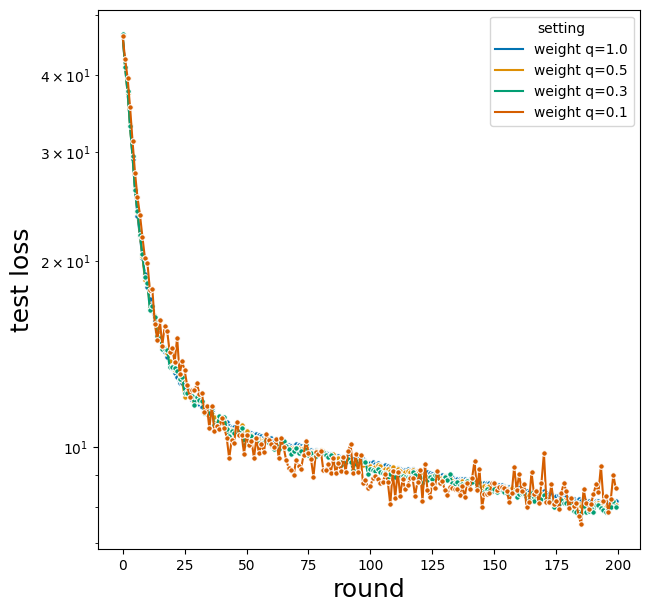

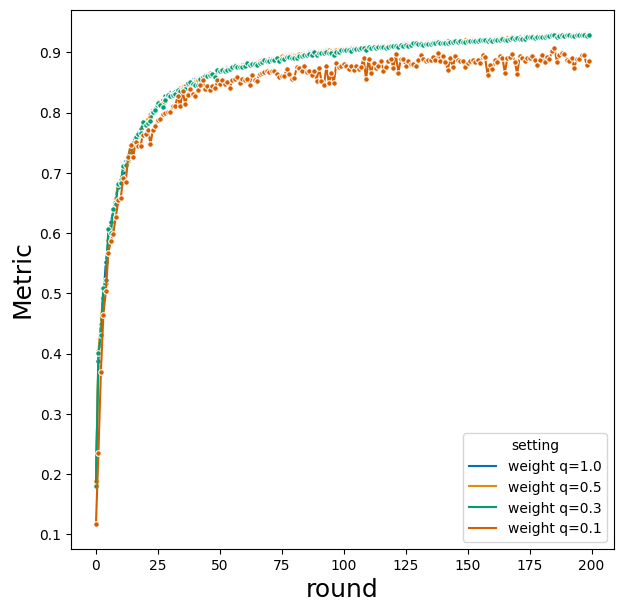

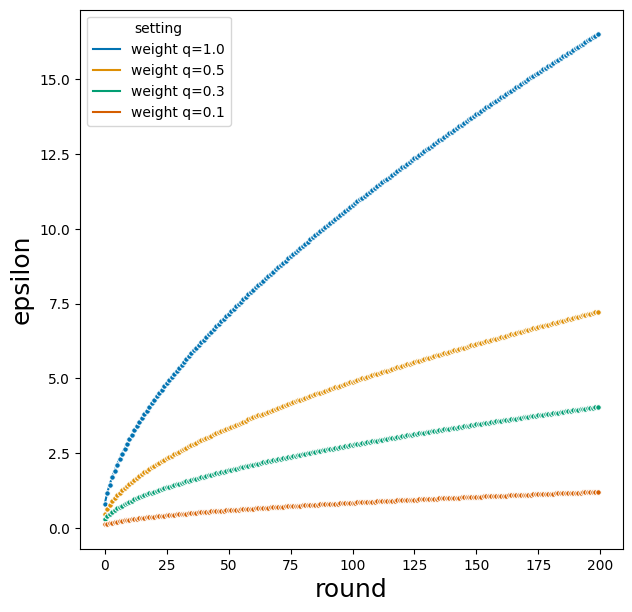

In [33]:
# MNIST sampling

setting_map = {0: "weight q=1.0", 1: "weight q=0.5", 2: "weight q=0.3", 3: "weight q=0.1"}

# .29で実行中

file_paths = [
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/7c4c11476f/sim-20230721065447-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/9bf45d2a1e/sim-20230718211030-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/add0a12493/sim-20230715192704-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/faeefd4231/sim-20230714093523-results.json",
 ]

plot_multiple_losses(file_paths, setting_map)
plot_multiple_metrics(file_paths, setting_map)
plot_multiple_epsilons(file_paths, setting_map)

Namespace(seed=0, gpu_id=None, silo_id=None, dataset_name='creditcard', model_name='cnn', n_users=1000, n_silos=5, user_dist='zipf', silo_dist='zipf', user_alpha=1.0, silo_alpha=1.5, n_labels=1, typical_scenaio=None, n_silo_per_round=5, n_total_round=100, local_epochs=30, local_learning_rate=0.01, global_learning_rate=10.0, local_batch_size=64, weight_decay=0.001, client_optimizer='sgd', agg_strategy='ULDP-AVG-w', group_k=2, sigma=5.0, clipping_bound=1.0, delta=1e-05, sampling_rate_q=0.5, verbose=1, hyper_parameter_tuning=None, times=5, exp_dist=None, version=0, dry_run=False)
Namespace(seed=0, gpu_id=None, silo_id=None, dataset_name='creditcard', model_name='cnn', n_users=1000, n_silos=5, user_dist='zipf', silo_dist='zipf', user_alpha=1.0, silo_alpha=1.5, n_labels=1, typical_scenaio=None, n_silo_per_round=5, n_total_round=100, local_epochs=30, local_learning_rate=0.01, global_learning_rate=10.0, local_batch_size=64, weight_decay=0.001, client_optimizer='sgd', agg_strategy='ULDP-AVG-ws

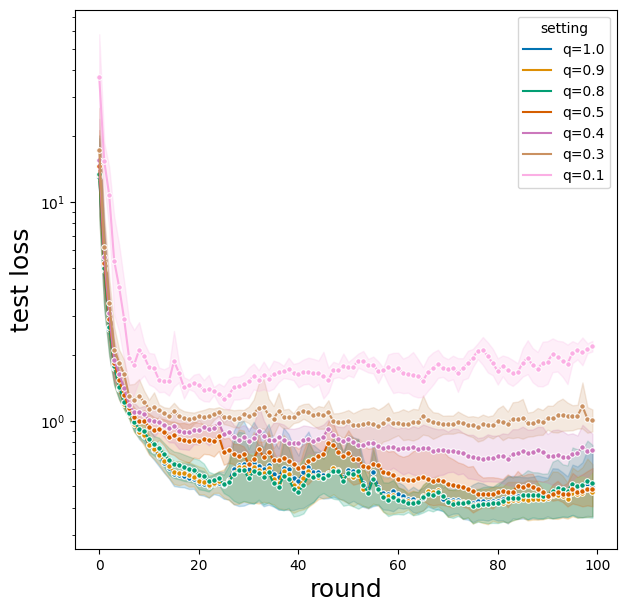

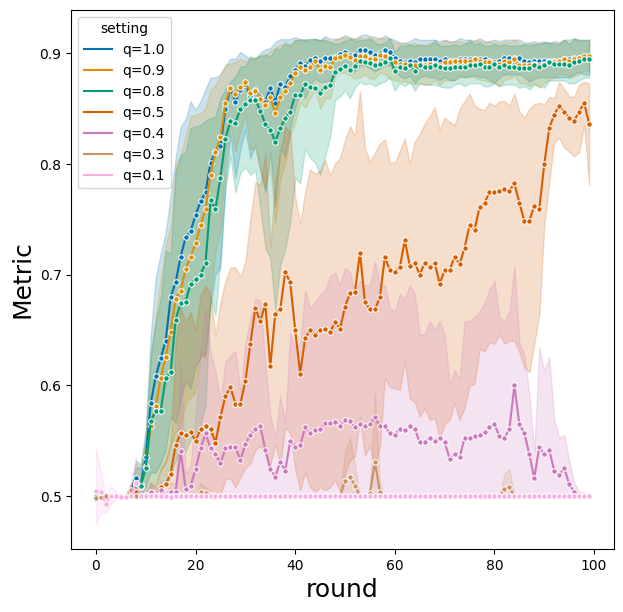

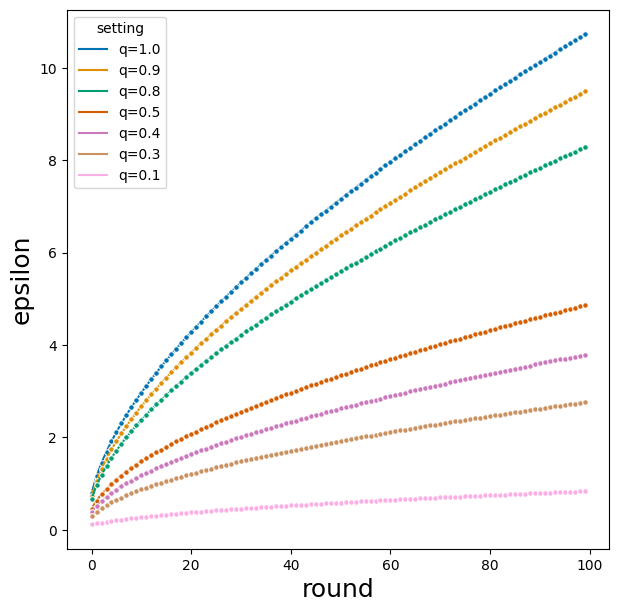

In [15]:
# Creditcard sampling

setting_map = {0: "q=1.0", 1: "q=0.9", 2: "q=0.8", 3: "q=0.5", 4: "q=0.4", 5: "q=0.3", 6: "q=0.1"}

# .197で実行中

# local_epochs=20, をlocal_epochs=30に統一する必要あり

file_paths = [
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/64db333c24/sim-20230713233941-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/d9a12dc021/sim-20230714182326-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/457af4c180/sim-20230715053649-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/aa04339fa5/sim-20230715123901-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/9071d40e67/sim-20230722101417-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/7d4fd293c3/sim-20230722101859-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/1343fa721e/sim-20230722043140-results.json",
]

plot_multiple_losses(file_paths, setting_map)
plot_multiple_metrics(file_paths, setting_map)
plot_multiple_epsilons(file_paths, setting_map)

In [40]:
get_file_path_from_hash("0623076dab")

sim-20230712101008-results.json /Users/fumiyuki/research/AcSilo/acsilo/exp/results/0623076dab/sim-20230712101008-results.json
